In [1]:
import numpy as np    # for numerical operation
import pandas as pd   # importing Data
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns   # Visualization

In [2]:
data= pd.read_csv("Loan_default.csv")   # Data Imported
data

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [3]:
df=data.copy()    #Create Copy of Data

In [4]:
df.head()    #Display First five Data

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


1) Income should be greter than 0.
3) IntrestRate should be greter than 1. 
4) Debt-to-Income Ratio(DTIRatio) range is 0 to 1.
5) LoanAmount and IntrestRate are related to each other, intrest ratio are dependant on Loan amount.
6) Income and Loan Amount are depends on each other. 
7) loan purpose and loan amount are depends on each others.
8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df["Age"].isna().sum()  #checking Null Values of Age 

0

In [7]:
df["Age"].value_counts()  # Total Value Counts of Age

55    5064
40    5056
65    5027
33    5022
53    5010
62    4999
34    4987
45    4985
61    4982
39    4973
22    4970
32    4969
43    4965
19    4963
35    4961
68    4958
38    4955
30    4954
49    4952
50    4949
27    4945
47    4931
57    4925
54    4921
31    4908
44    4906
36    4906
28    4906
56    4902
26    4891
21    4889
46    4887
18    4884
58    4883
67    4876
51    4876
59    4871
24    4869
29    4865
63    4862
20    4861
37    4856
66    4841
25    4840
64    4840
69    4817
41    4815
48    4810
42    4803
60    4772
52    4748
23    4740
Name: Age, dtype: int64

In [8]:
df['Age'].unique()

array([56, 69, 46, 32, 60, 25, 38, 36, 40, 28, 41, 53, 57, 20, 39, 19, 61,
       47, 55, 50, 29, 42, 66, 44, 59, 45, 33, 64, 68, 54, 24, 26, 35, 21,
       31, 67, 43, 37, 52, 34, 23, 51, 27, 48, 65, 62, 58, 18, 22, 30, 49,
       63], dtype=int64)

In [9]:
df["Income"].isnull().sum()  #checking Null Values of Income

0

In [10]:
df['Income'].value_counts()  #Total Value Counts of Income

69492     10
117102    10
121985    10
85375      9
61315      9
          ..
98969      1
72350      1
126600     1
68356      1
124446     1
Name: Income, Length: 114620, dtype: int64

In [11]:
df["Income"].min()   # Minimum Income 

15000

In [12]:
df["Income"].max()  # Maximum Income

149999

In [13]:
df["LoanAmount"].isna().sum()   # Checking Null values of LoanAmount

0

In [14]:
df["LoanAmount"].value_counts()   # Total value_count of LoanAmount

133724    8
221949    8
95419     8
235258    7
108323    7
         ..
121259    1
147115    1
166792    1
39044     1
208294    1
Name: LoanAmount, Length: 158729, dtype: int64

In [15]:
df['LoanAmount'].min()  # minimum LoanAmount

5000

In [16]:
df['LoanAmount'].max()  # Maximum LoanAmount

249999

In [17]:
df['CreditScore'].isna().sum()  #Checking null values of Creditscore

0

In [18]:
df['CreditScore'].value_counts() #Total Value_ounts of CreditScore

630    528
445    521
829    520
753    519
670    515
      ... 
629    408
706    406
536    406
720    402
724    392
Name: CreditScore, Length: 550, dtype: int64

In [19]:
df['CreditScore'].min()   #minimum credit score

300

In [20]:
df['CreditScore'].max()  #maximum credit score

849

In [21]:
df["MonthsEmployed"].isnull().sum() #checking null values

0

In [22]:
df['MonthsEmployed'].value_counts().sort_values() #total value count

25     2004
99     2008
21     2014
39     2041
11     2043
       ... 
17     2198
107    2207
45     2220
26     2223
56     2227
Name: MonthsEmployed, Length: 120, dtype: int64

In [23]:
df['MonthsEmployed'].max()  #max value of MonthEmployed

119

In [24]:
df['MonthsEmployed'].min()

0

In [25]:
df["Education"].value_counts()

Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: Education, dtype: int64

In [26]:
df["EmploymentType"].value_counts()

Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: EmploymentType, dtype: int64

In [27]:
df["MaritalStatus"].value_counts()

Married     85302
Divorced    85033
Single      85012
Name: MaritalStatus, dtype: int64

In [28]:
df["HasMortgage"].value_counts()

Yes    127677
No     127670
Name: HasMortgage, dtype: int64

In [29]:
df["HasDependents"].value_counts()

Yes    127742
No     127605
Name: HasDependents, dtype: int64

In [30]:
df["LoanPurpose"].value_counts()

Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: LoanPurpose, dtype: int64

In [31]:
df["HasCoSigner"].value_counts()

Yes    127701
No     127646
Name: HasCoSigner, dtype: int64

In [32]:
average_loan_amount_by_purpose = df.groupby('LoanPurpose')['LoanAmount'].mean()
average_loan_amount_by_purpose

LoanPurpose
Auto         127857.908721
Business     127141.807458
Education    127645.822841
Home         127622.382853
Other        127629.648054
Name: LoanAmount, dtype: float64

In [33]:
total_loan_amount_by_purpose = df.groupby('LoanPurpose')['LoanAmount'].sum()
total_loan_amount_by_purpose

LoanPurpose
Auto         6500807511
Business     6522120439
Education    6510575194
Home         6545241527
Other        6498135901
Name: LoanAmount, dtype: int64

In [34]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
obj_col = ['HasCoSigner','LoanPurpose','HasDependents', 'HasMortgage','MaritalStatus', 'EmploymentType', 'Education']


for col in obj_col:
    df[col] = le.fit_transform(df[col])
    
df=df.drop(["LoanID"],axis=1)

In [35]:
df.dtypes

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education           int32
EmploymentType      int32
MaritalStatus       int32
HasMortgage         int32
HasDependents       int32
LoanPurpose         int32
HasCoSigner         int32
Default             int64
dtype: object

In [36]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [37]:
df["Default"].value_counts()

0    225694
1     29653
Name: Default, dtype: int64

In [38]:
df["Default"].isna().sum()

0

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  int32  
 10  EmploymentType  255347 non-null  int32  
 11  MaritalStatus   255347 non-null  int32  
 12  HasMortgage     255347 non-null  int32  
 13  HasDependents   255347 non-null  int32  
 14  LoanPurpose     255347 non-null  int32  
 15  HasCoSigner     255347 non-null  int32  
 16  Default         255347 non-null  int64  
dtypes: float64

In [40]:
df.drop(columns=['HasCoSigner','Education'], inplace=True)

In [41]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,1.500096,0.999918,0.500014,0.500268,2.000501,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,1.117358,0.816051,0.500001,0.500001,1.412723,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,2.000000,2.000000,1.000000,1.000000,3.000000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,3.000000,2.000000,1.000000,1.000000,4.000000,1.000000


In [42]:
X=df.drop("Default",axis=True)

In [43]:
y=df["Default"]

In [44]:
df.corr()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,0.000787,-0.002187,0.000035,0.000710,0.002264,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.005146,0.000637,-0.000945,-0.001570,-0.002092,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.003060,-0.000771,-0.000801,0.000139,0.000057,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,0.003503,-0.003218,0.001728,-0.003018,0.000596,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,0.000564,-0.000095,0.000210,0.001450,-0.002579,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.000219,-0.000664,-0.001744,-0.001895,0.000340,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.000525,-0.005079,-0.000424,-0.000243,0.001472,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000779,-0.001042,0.001775,0.002417,0.002856,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,-0.000578,0.004492,0.000231,0.001492,-0.003819,0.019236
EmploymentType,0.000787,-0.005146,0.003060,0.003503,0.000564,0.000219,0.000525,0.000779,-0.000578,1.000000,0.002768,0.001193,0.002480,0.000734,0.041010


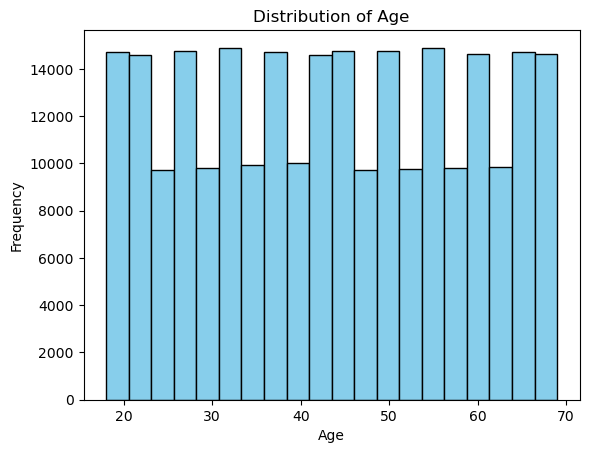

In [45]:

# Example: Histogram of the 'Age' column
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


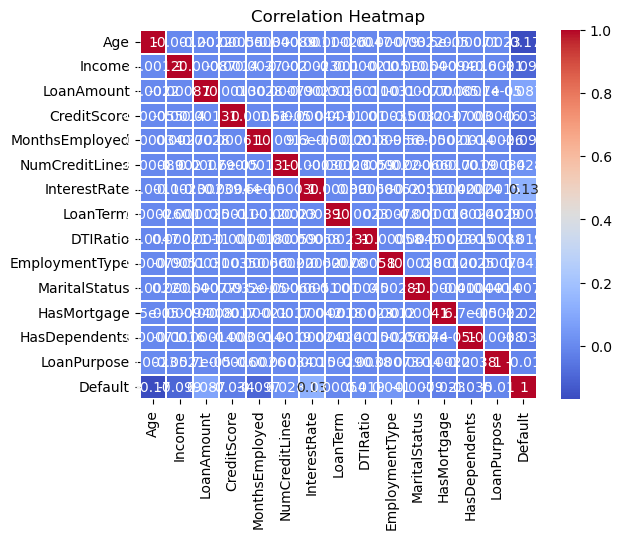

In [46]:
# Example: Correlation heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.1)
plt.title('Correlation Heatmap')
plt.show()


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=25)

In [49]:
X_train

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose
186472,29,112646,182528,809,38,3,6.48,36,0.55,3,0,1,1,1
31922,56,87690,123629,365,108,2,19.82,48,0.89,1,0,0,1,2
165958,64,64576,185728,314,5,4,17.37,12,0.33,3,2,1,1,0
213151,39,22030,7951,552,99,1,9.98,48,0.14,1,1,0,0,2
200924,62,66214,149449,504,90,2,5.78,24,0.43,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130365,65,125536,167625,584,92,4,6.79,24,0.22,3,1,0,0,0
92303,27,111747,181383,671,43,3,21.48,60,0.57,3,2,1,0,3
6618,31,44965,9259,332,31,1,9.15,60,0.64,3,0,0,1,2
90430,39,130304,60289,378,54,4,23.93,48,0.10,1,0,1,1,1


In [50]:
y_train

186472    0
31922     0
165958    0
213151    0
200924    0
         ..
130365    0
92303     0
6618      0
90430     0
29828     0
Name: Default, Length: 178742, dtype: int64

In [51]:
X_test

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose
140559,69,42760,52388,569,53,4,8.25,12,0.38,3,2,1,1,3
182583,46,56829,80946,444,12,1,24.56,36,0.12,0,2,0,0,3
117305,31,148403,120484,562,40,2,23.20,12,0.56,2,1,1,0,1
88742,44,119311,249747,324,118,4,14.50,60,0.51,3,2,1,0,3
88912,39,15687,138180,639,24,1,2.34,24,0.27,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146496,27,61999,60814,765,105,3,3.35,36,0.19,2,2,1,0,2
171096,47,40399,93952,365,108,3,9.21,48,0.31,2,0,1,1,3
253543,18,68103,55445,305,32,3,2.64,24,0.10,3,2,0,1,2
110875,40,141711,109151,483,56,3,20.72,36,0.86,2,1,1,1,0


In [52]:
y_test

140559    0
182583    0
117305    0
88742     0
88912     0
         ..
146496    0
171096    0
253543    0
110875    0
47990     0
Name: Default, Length: 76605, dtype: int64

In [53]:
#Random Forest 
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [54]:
y_pred=rfc.predict(X_test)

In [55]:
accuracy_score(y_test,y_pred)

0.8844853469094707

In [56]:
f1=f1_score(y_test,y_pred)
f1

0.07562937428183433

In [57]:
confusion_matrix(y_test,y_pred)

array([[67394,   231],
       [ 8618,   362]], dtype=int64)

In [58]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

In [59]:
model=GradientBoostingClassifier()
model.fit(X_train,y_train)

GradientBoostingClassifier()

In [60]:
y_pred=model.predict(X_test)

In [61]:
precision_score(y_test,y_pred)

0.6419400855920114

In [62]:
recall_score(y_test,y_pred)

0.05011135857461024

In [63]:
f1=f1_score(y_test,y_pred)
f1

0.09296560272699102

In [64]:
accuracy_score(y_test,y_pred)

0.8853730174270609

In [65]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

In [66]:
Lmodel=LogisticRegression()
Lmodel.fit(X_train,y_train)

LogisticRegression()

In [67]:
y_pred=Lmodel.predict(X_test)


In [68]:
precision_score(y_test,y_pred)

0.7368421052631579

In [69]:
recall_score(y_test,y_pred)

0.0015590200445434299

In [70]:
f1_score(y_test,y_pred)

0.003111456828536504

In [71]:
accuracy_score(y_test,y_pred)

0.8828927615690881